<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 36 · Probability</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Probability by Simulation 🎲</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:730px;line-height:1.6">When a probability is hard to derive, you can estimate it: run the random experiment thousands of times and count. This notebook estimates a probability, throws random darts to approximate pi, watches the error shrink like 1/sqrt(N), settles the Monty Hall paradox, and bootstraps a confidence interval, all with the Monte Carlo method.</div>
  <div style="margin-top:16px;font-size:13px;color:#cbd5e1">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(36)
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False})
INDIGO="#4f46e5"; PINK="#db2777"; GRAY="#94a3b8"
print("ready")

ready


<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4f46e5;letter-spacing:1px">DEMO 1 · THE MONTE CARLO LOOP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Estimate a probability by counting</div>
<div style="color:#4a5578;margin-top:6px">The whole method in one line: run the experiment N times, count the successes, divide. Here is P(at least one six in four rolls), which we also know exactly from the complement rule.</div>
</div>

In [2]:
N = 500_000
rolls = rng.integers(1, 7, size=(N, 4))          # N experiments of 4 dice each
at_least_one_six = (rolls == 6).any(axis=1)       # success in each experiment
estimate = at_least_one_six.mean()
exact = 1 - (5/6)**4
print(f"Monte Carlo estimate = {estimate:.4f}")
print(f"exact 1 - (5/6)^4    = {exact:.4f}")

Monte Carlo estimate = 0.5168
exact 1 - (5/6)^4    = 0.5177


The estimate lands right on the exact value 0.5177. That is the entire idea: a probability is a long-run frequency (Chapter 30), so simulating the long run and counting *is* a measurement of the probability. The same loop estimates an expectation, just average the values instead of counting hits.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4f46e5;letter-spacing:1px">DEMO 2 · ESTIMATING PI WITH DARTS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Geometry from randomness</div>
<div style="color:#4a5578;margin-top:6px">Throw random darts at a unit square. The fraction landing inside the quarter circle is pi/4, because that is the ratio of the areas. Multiply by 4 to estimate pi.</div>
</div>

In [3]:
N = 100_000
x = rng.random(N); y = rng.random(N)
inside = x**2 + y**2 <= 1.0
pi_est = 4 * inside.mean()
print(f"fraction inside quarter circle = {inside.mean():.4f}  (theory pi/4 = {np.pi/4:.4f})")
print(f"pi estimate = 4 x fraction = {pi_est:.4f}  (true pi = {np.pi:.4f})")

fraction inside quarter circle = 0.7854  (theory pi/4 = 0.7854)
pi estimate = 4 x fraction = 3.1414  (true pi = 3.1416)


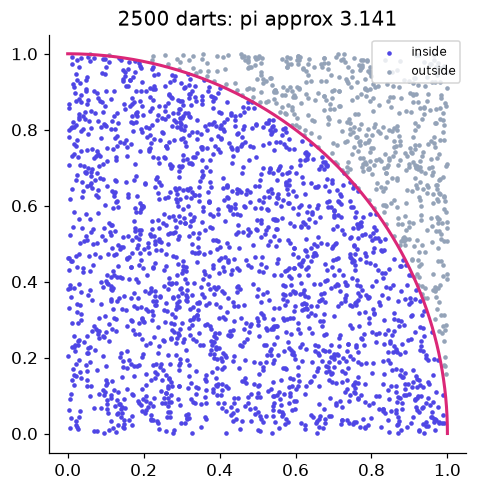

In [4]:
fig,ax=plt.subplots(figsize=(4.6,4.6))
samp=2500
ax.scatter(x[:samp][inside[:samp]],  y[:samp][inside[:samp]],  s=4, color=INDIGO, label="inside")
ax.scatter(x[:samp][~inside[:samp]], y[:samp][~inside[:samp]], s=4, color=GRAY,   label="outside")
th=np.linspace(0,np.pi/2,200); ax.plot(np.cos(th), np.sin(th), color=PINK, lw=2)
ax.set_aspect("equal"); ax.set_title(f"{samp} darts: pi approx {pi_est:.3f}"); ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

No formula for pi was used, only random points and an area ratio. This is Monte Carlo integration in miniature: a hard quantity (an area, an integral, an expectation) becomes an average over random samples.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4f46e5;letter-spacing:1px">DEMO 3 · HOW THE ERROR SHRINKS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The 1/sqrt(N) law</div>
<div style="color:#4a5578;margin-top:6px">Simulation is not free: the estimate has its own random error. That error falls like 1/sqrt(N), so to halve it you need four times as many samples.</div>
</div>

In [5]:
Ns = np.array([100, 300, 1000, 3000, 10_000, 30_000, 100_000, 300_000])
errs = []
for n in Ns:
    xs = rng.random(n); ys = rng.random(n)
    est = 4*((xs**2+ys**2)<=1).mean()
    errs.append(abs(est - np.pi))
for n,e in zip(Ns,errs):
    print(f"N={n:7d}   |error| = {e:.4f}")

N=    100   |error| = 0.1016
N=    300   |error| = 0.2584
N=   1000   |error| = 0.0936
N=   3000   |error| = 0.0803
N=  10000   |error| = 0.0064
N=  30000   |error| = 0.0129
N= 100000   |error| = 0.0067
N= 300000   |error| = 0.0008


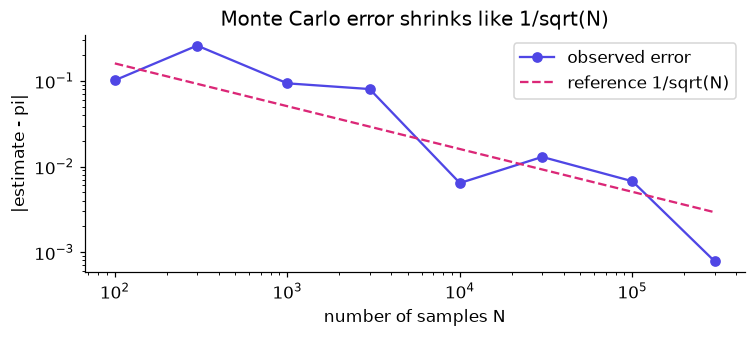

In [6]:
fig,ax=plt.subplots(figsize=(7,3.2))
ax.loglog(Ns, errs, "o-", color=INDIGO, label="observed error")
ax.loglog(Ns, 1.6/np.sqrt(Ns), "--", color=PINK, label="reference 1/sqrt(N)")
ax.set_xlabel("number of samples N"); ax.set_ylabel("|estimate - pi|")
ax.set_title("Monte Carlo error shrinks like 1/sqrt(N)"); ax.legend()
plt.tight_layout(); plt.show()

On log-log axes the error tracks a straight line of slope -1/2: the signature of 1/sqrt(N) convergence. The practical lesson is sobering, getting one more decimal place of accuracy costs about 100 times more samples. Simulation is easy to write but can be expensive to make precise.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4f46e5;letter-spacing:1px">DEMO 4 · THE MONTY HALL PARADOX</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">When intuition fails, simulate</div>
<div style="color:#4a5578;margin-top:6px">Three doors, a car behind one. You pick a door; the host opens a different door revealing a goat, then offers a switch. Should you switch? Simulation settles the famous argument.</div>
</div>

In [7]:
N = 200_000
car  = rng.integers(0, 3, N)        # where the car is
pick = rng.integers(0, 3, N)        # the contestant's first guess
# Key fact: after the host reveals a goat, SWITCHING wins exactly when the first pick was wrong.
stay_wins   = (pick == car).mean()
switch_wins = (pick != car).mean()
print(f"P(win | stay)   = {stay_wins:.4f}   (theory 1/3 = {1/3:.4f})")
print(f"P(win | switch) = {switch_wins:.4f}   (theory 2/3 = {2/3:.4f})")

P(win | stay)   = 0.3362   (theory 1/3 = 0.3333)
P(win | switch) = 0.6638   (theory 2/3 = 0.6667)


Switching wins about **2/3** of the time, double the odds of staying. The intuition trap is treating the two remaining doors as 50/50; in fact the host's choice is not random, it leaks information, and switching captures it. A skeptic can argue forever, but 200,000 simulated games end the debate.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#4f46e5;letter-spacing:1px">DEMO 5 · THE BOOTSTRAP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Monte Carlo on your own data</div>
<div style="color:#4a5578;margin-top:6px">You have one sample and want a confidence interval for its mean, with no formula. The bootstrap resamples your data with replacement thousands of times, a Monte Carlo estimate of the sampling distribution.</div>
</div>

In [8]:
sample = rng.normal(50, 12, size=40)        # one sample of 40 observations
B = 10_000
boot_means = np.array([rng.choice(sample, size=len(sample), replace=True).mean() for _ in range(B)])
lo, hi = np.percentile(boot_means, [2.5, 97.5])
print(f"sample mean              = {sample.mean():.2f}")
print(f"bootstrap 95% CI for mean = [{lo:.2f}, {hi:.2f}]")

sample mean              = 49.83
bootstrap 95% CI for mean = [46.94, 52.72]


By resampling the data itself, the bootstrap builds a whole distribution of plausible means and reads a confidence interval straight off the percentiles, no algebra required. It is one of the most quietly powerful tools in data science, and it is pure Monte Carlo.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ What you built</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You estimated a probability by counting, approximated pi with random darts, measured the 1/sqrt(N) error law, settled Monty Hall, and bootstrapped a confidence interval. Whenever a probability, an expectation, or an interval is hard to derive, you can now simulate it instead, the method that closes Part VI and reappears throughout machine learning.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>